# Tutorial - Coliop - Parte 2c - Criando instâncias com **pyCmpl** no Google Colab

# 1. Configuração do Ambiente

Nesta etapa, configuramos o ambiente do Google Colab para utilizar a linguagem de otimização **CMPL**.

Essa célula deve ser executada apenas:
- Ao abrir o notebook pela primeira vez
- Ou quando o ambiente for reiniciado/desconectado

O que será feito:
- Download do COLIOP/CMPL (disponível em [coliop.org](https://www.coliop.org/download.html))
- Extração dos arquivos
- Configuração de variáveis de ambiente
- Inclusão das bibliotecas no Python

In [1]:
### Esta célula dever ser executada apenas quando o notebook for aberto
### ou quando o ambiente for desconectado e for necessário reconectá-lo
### por inatividade!

# Importação de bibliotecas do sistema
import os, sys

# Baixa o pacote do CMPL a partir do site oficial
os.system("wget https://www.coliop.org/_download/Cmpl-2-1-0-linux64.tar.gz")

# Extrai o arquivo baixado
os.system("tar -xzf Cmpl-2-1-0-linux64.tar.gz")

# Define o diretório principal do CMPL
os.environ["CMPLHOME"] = "/content/Cmpl-2-1-0-linux64"

# Adiciona o executável do CMPL ao PATH do sistema
os.environ["PATH"] += ":/content/Cmpl-2-1-0-linux64/bin"

# Configura bibliotecas compartilhadas necessárias
os.environ["LD_LIBRARY_PATH"] = "/content/Cmpl-2-1-0-linux64/bin/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

# Adiciona os módulos Python do CMPL ao caminho de importação
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/lib3")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/scripts/Unix")

# 2. Definição do Modelo de Otimização (Exemplo 1 da Aula 03 do Tutorial)

Aqui definimos um problema de **programação linear inteira** usando a linguagem do CMPL.

## 2.1 Objetivo:
Minimizar o custo total de produtos.

## 2.2 Elementos do modelo:
- **Plantas**: Conjunto de pontos de oferta (plantas).
- **Centros**: Conjunto de pontos de demanda (centros).
- **Custos**: custos por unidade enviada.
- **Oferta**: Quantidade ofertada pelas plantas de produção.
- **Demanda**: Quantidade demandada pelos centros de consumo.

## 2.3 Variável de decisão:
- `x[i,j]`: quantidade enviadas da planta `𝑖` para o centro `𝑗`.

In [2]:
# Definição do modelo geral (generalizado) em linguagem CMPL (como string)
codigo_cmpl = """
%solver highs  // Resolvedor adotado: HiGHS - High Performance Optimization Software
%opt highs solver='choose' ### Opções do resolvedor adotado. Parâmetro interno solver: "choose", "simplex", "ipm", "ipx", "hipo" or "pdlp". ### solver='choose' define internamente se o problema é um LP, MIP ou QP.
par:
// Conjuntos
I:=set(1..3); // conjunto de plantas
J:=set(1..4); // conjunto de centros

// Parametros
O[I]:=(5000,6000,2500); // Oferta em unidades da planta i
D[J]:=(6000,4000,2000,1500); // Demanda em unidades do centro j
C[I,J]:=((3,2,7,6),(7,5,2,3),(2,5,4,5)); // Custo em unidades de envio da planta i para o centro j

var:
x[I,J]: int[0..]; // Numero de unidades enviadas da planta 𝑖 para o centro 𝑗

obj:FO: sum{i in I, j in J: C[i,j] * x[i,j] } ->min; // minimizar o custo total

con:
Ofertas {i in I : sum{j in J: x[i,j]} = O[i];} //Restricoes de Oferta
Demandas {j in J: sum{i in I: x[i,j]} = D[j]; } //Restricoes de Demanda

"""

# Salva o modelo em um arquivo .cmpl
with open("/content/problema_de_transporte_unico.cmpl", "w") as f:
    f.write(codigo_cmpl)

# 3. Resolução do Modelo

Nesta etapa utilizamos a **API Python pyCmpl** para fazer a integração entre modelo e resolvedor:
1. Carregamos o modelo criado
2. Executamos o solver
3. Exibimos o relatório da solução
4. Tratamento de erro para capturar possíveis problemas.

Também é possível fazer a entrada de dados por um arquivo python, atribuindo valores para conjuntos e parâmetros do modelo, utilizando atributos e métodos do pyCmpl. Isto será objeto para outra aula.

In [4]:
# Importa a biblioteca do CMPL para Python
from pyCmpl import *

try:
    # Cria o objeto do modelo a partir do arquivo
    modelo = Cmpl("/content/problema_de_transporte_unico.cmpl")

    # Resolve o problema de otimização
    modelo.solve()

    # Exibe o relatório da solução (valores ótimos)
    modelo.solutionReport()

except CmplException as e:
    # Caso ocorra erro, exibe a mensagem
    print(e.msg)

---------------------------------------------------------------------------------------------------------
Problem              problema_de_transporte_unico.cmpl
Nr. of variables     12
Nr. of constraints   7
Objective name       FO
Solver name          HIGHS
Display variables    (all)
Display constraints  (all)
---------------------------------------------------------------------------------------------------------

Objective status     INTEGER OPTIMAL
Objective value      39500.00            (min!)

Variables           
Name                 Type            Activity          LowerBound          UpperBound            Marginal
---------------------------------------------------------------------------------------------------------
x[1,1]                  I                3500                0.00                 inf                   -
x[1,2]                  I                1500                0.00                 inf                   -
x[1,3]                  I                   0    

In [5]:
#@title Função para criação do grafo
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

def extrair_dados_transporte(modelo):
    """
    Extrai os dados da solução de um modelo de transporte CMPL.

    Retorna
    -------
    dict
        Dicionário contendo ofertas, demandas e fluxos.
    """

    ofertas = {
        i: float(v.activity)
        for i, v in modelo.Ofertas.items()
    }

    demandas = {
        j: float(v.activity)
        for j, v in modelo.Demandas.items()
    }

    fluxos = {
        (i, j): float(v.activity)
        for (i, j), v in modelo.x.items()
    }

    return {
        "ofertas": ofertas,
        "demandas": demandas,
        "fluxos": fluxos
    }


def grafo_transporte(
    dados,
    figsize=(15, 9),
    titulo="Solução Ótima do Problema de Transporte",
    mostrar_rotas_nao_utilizadas=True,
    mostrar_quantidades=True,
    node_size=3500,
    distancia_x=6,
    espacamento_plantas=2,
    espacamento_centros=1.5
):
    """
    Gera um grafo para representar a solução de um
    problema de transporte.

    Parâmetros
    ----------
    dados : dict
        Dicionário produzido por extrair_dados_transporte().

    figsize : tuple
        Tamanho da figura.

    titulo : str
        Título do gráfico.

    mostrar_rotas_nao_utilizadas : bool
        Mostra as rotas de fluxo zero.

    mostrar_quantidades : bool
        Mostra os fluxos sobre as arestas.

    Retorna
    -------
    G, pos
        Grafo NetworkX e posições dos nós.
    """

    # ========================================================
    # 1. RECUPERAR OS DADOS
    # ========================================================

    ofertas = dados["ofertas"]
    demandas = dados["demandas"]
    fluxos = dados["fluxos"]


    # ========================================================
    # 2. CRIAR GRAFO
    # ========================================================

    G = nx.DiGraph()


    # ========================================================
    # 3. ADICIONAR PLANTAS
    # ========================================================

    for i, oferta in ofertas.items():

        G.add_node(
            f"P{i}",
            tipo="planta",
            indice=i,
            valor=oferta,
            label=f"Planta {i}"
        )


    # ========================================================
    # 4. ADICIONAR CENTROS
    # ========================================================

    for j, demanda in demandas.items():

        G.add_node(
            f"C{j}",
            tipo="centro",
            indice=j,
            valor=demanda,
            label=f"Centro {j}"
        )


    # ========================================================
    # 5. ADICIONAR ROTAS
    # ========================================================

    for (i, j), quantidade in fluxos.items():

        G.add_edge(
            f"P{i}",
            f"C{j}",
            quantidade=quantidade,
            utilizada=quantidade > 0
        )


    # ========================================================
    # 6. POSICIONAMENTO
    # ========================================================

    pos = {}

    for k, i in enumerate(ofertas):

        pos[f"P{i}"] = (
            0,
            -k * espacamento_plantas
        )

    for k, j in enumerate(demandas):

        pos[f"C{j}"] = (
            distancia_x,
            -k * espacamento_centros
        )


    # ========================================================
    # 7. SEPARAR ROTAS
    # ========================================================

    rotas_utilizadas = [
        (u, v)
        for u, v, dados_aresta in G.edges(data=True)
        if dados_aresta["utilizada"]
    ]

    rotas_nao_utilizadas = [
        (u, v)
        for u, v, dados_aresta in G.edges(data=True)
        if not dados_aresta["utilizada"]
    ]


    # ========================================================
    # 8. ESCALA DAS ARESTAS
    # ========================================================

    if rotas_utilizadas:

        maior_fluxo = max(
            G[u][v]["quantidade"]
            for u, v in rotas_utilizadas
        )

    else:

        maior_fluxo = 1


    larguras = [
        1.5 + 7 *
        G[u][v]["quantidade"] /
        maior_fluxo

        for u, v in rotas_utilizadas
    ]


    # ========================================================
    # 9. FIGURA
    # ========================================================

    fig, ax = plt.subplots(
        figsize=figsize
    )


    # ========================================================
    # 10. ROTAS NÃO UTILIZADAS
    # ========================================================

    if mostrar_rotas_nao_utilizadas:

        nx.draw_networkx_edges(
            G,
            pos,

            edgelist=rotas_nao_utilizadas,

            edge_color="#BDBDBD",

            width=1.2,

            style="dashed",

            alpha=0.6,

            arrows=True,

            arrowsize=12,

            arrowstyle="-|>",

            connectionstyle="arc3,rad=0.03"
        )


    # ========================================================
    # 11. ROTAS UTILIZADAS
    # ========================================================

    nx.draw_networkx_edges(
        G,
        pos,

        edgelist=rotas_utilizadas,

        edge_color="#1565C0",

        width=larguras,

        alpha=0.9,

        arrows=True,

        arrowsize=22,

        arrowstyle="-|>",

        connectionstyle="arc3,rad=0.03"
    )


    # ========================================================
    # 12. PLANTAS
    # ========================================================

    nx.draw_networkx_nodes(
        G,
        pos,

        nodelist=[
            f"P{i}"
            for i in ofertas
        ],

        node_color="#1565C0",

        node_size=node_size,

        node_shape="s",

        edgecolors="white",

        linewidths=2
    )


    # ========================================================
    # 13. CENTROS
    # ========================================================

    nx.draw_networkx_nodes(
        G,
        pos,

        nodelist=[
            f"C{j}"
            for j in demandas
        ],

        node_color="#2E7D32",

        node_size=node_size,

        node_shape="o",

        edgecolors="white",

        linewidths=2
    )


    # ========================================================
    # 14. NOMES DOS NÓS
    # ========================================================

    labels = nx.get_node_attributes(
        G,
        "label"
    )

    nx.draw_networkx_labels(
        G,
        pos,

        labels=labels,

        font_size=10,

        font_weight="bold",

        font_color="white"
    )


    # ========================================================
    # 15. OFERTA ACIMA DAS PLANTAS
    # ========================================================

    for i, oferta in ofertas.items():

        x, y = pos[f"P{i}"]

        ax.text(
            x,
            y + 0.65,

            f"Oferta: {oferta:,.0f}",

            ha="center",
            va="bottom",

            fontsize=10,
            fontweight="bold",

            color="#1565C0",

            bbox=dict(
                facecolor="white",
                edgecolor="#90CAF9",
                boxstyle="round,pad=0.25",
                alpha=0.95
            )
        )


    # ========================================================
    # 16. DEMANDA ACIMA DOS CENTROS
    # ========================================================

    for j, demanda in demandas.items():

        x, y = pos[f"C{j}"]

        ax.text(
            x,
            y + 0.65,

            f"Demanda: {demanda:,.0f}",

            ha="center",
            va="bottom",

            fontsize=10,
            fontweight="bold",

            color="#2E7D32",

            bbox=dict(
                facecolor="white",
                edgecolor="#A5D6A7",
                boxstyle="round,pad=0.25",
                alpha=0.95
            )
        )


    # ========================================================
    # 17. QUANTIDADES NAS ROTAS
    # ========================================================

    if mostrar_quantidades:

        edge_labels = {
            (u, v):
            f'{G[u][v]["quantidade"]:,.0f}'

            for u, v in rotas_utilizadas
        }

        nx.draw_networkx_edge_labels(
            G,
            pos,

            edge_labels=edge_labels,

            font_size=10,

            font_weight="bold",

            font_color="#0D47A1",

            label_pos=0.5,

            bbox=dict(
                facecolor="white",
                edgecolor="#90CAF9",
                boxstyle="round,pad=0.25",
                alpha=0.9
            )
        )


    # ========================================================
    # 18. TÍTULO
    # ========================================================

    ax.set_title(
        titulo,

        fontsize=20,

        fontweight="bold",

        pad=25
    )


    # ========================================================
    # 19. SUBTÍTULO
    # ========================================================

    ax.text(
        0.5,
        1.02,

        "Dados extraídos diretamente do modelo CMPL",

        transform=ax.transAxes,

        ha="center",

        fontsize=12,

        color="#555555"
    )


    # ========================================================
    # 20. LEGENDA
    # ========================================================

    legenda = [

        Line2D(
            [0], [0],
            color="#1565C0",
            linewidth=5,
            label="Rota utilizada"
        ),

        Line2D(
            [0], [0],
            color="#BDBDBD",
            linewidth=1.5,
            linestyle="--",
            label="Rota não utilizada"
        ),

        Line2D(
            [0], [0],
            marker="s",
            color="w",
            markerfacecolor="#1565C0",
            markersize=14,
            label="Planta"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="#2E7D32",
            markersize=14,
            label="Centro de demanda"
        )
    ]

    ax.legend(
        handles=legenda,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=4,
        frameon=False
    )


    # ========================================================
    # 21. FINALIZAÇÃO
    # ========================================================

    ax.axis("off")

    plt.tight_layout()

    plt.show()


    return None

def visualizar_transporte(
    modelo,
    retornar_grafo=False,
    **kwargs
):

    dados = extrair_dados_transporte(modelo)
    grafo_transporte(dados,**kwargs)


def heatmap_transporte(
    dados,
    figsize=(10, 7),
    titulo="Plano Ótimo de Transporte",
    cmap="Blues",
    mostrar_valores=True
):
    """
    Gera um heatmap dos fluxos de transporte.

    Os valores são obtidos diretamente dos dados
    extraídos do modelo CMPL.
    """

    ofertas = dados["ofertas"]
    demandas = dados["demandas"]
    fluxos = dados["fluxos"]

    plantas = list(ofertas.keys())
    centros = list(demandas.keys())

    # ---------------------------------------------
    # Construir matriz
    # ---------------------------------------------

    matriz = np.array([
        [
            fluxos.get((i, j), 0)
            for j in centros
        ]
        for i in plantas
    ])

    # ---------------------------------------------
    # Figura
    # ---------------------------------------------

    fig, ax = plt.subplots(
        figsize=figsize
    )

    im = ax.imshow(
        matriz,
        cmap=cmap,
        aspect="auto"
    )

    # ---------------------------------------------
    # Eixos
    # ---------------------------------------------

    ax.set_xticks(
        range(len(centros))
    )

    ax.set_xticklabels(
        [
            f"Centro {j}"
            for j in centros
        ]
    )

    ax.set_yticks(
        range(len(plantas))
    )

    ax.set_yticklabels(
        [
            f"Planta {i}"
            for i in plantas
        ]
    )

    ax.set_xlabel(
        "Centros de demanda"
    )

    ax.set_ylabel(
        "Plantas"
    )

    # ---------------------------------------------
    # Valores nas células
    # ---------------------------------------------

    if mostrar_valores:

        maior_valor = matriz.max()

        for i in range(len(plantas)):

            for j in range(len(centros)):

                valor = matriz[i, j]

                # Texto branco nos valores altos
                # e preto nos valores baixos

                cor = (
                    "white"
                    if valor > maior_valor * 0.5
                    else "black"
                )

                ax.text(
                    j,
                    i,

                    f"{valor:,.0f}",

                    ha="center",
                    va="center",

                    color=cor,

                    fontsize=11,

                    fontweight="bold"
                )

    # ---------------------------------------------
    # Colorbar
    # ---------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax
    )

    cbar.set_label(
        "Quantidade transportada"
    )

    # ---------------------------------------------
    # Título
    # ---------------------------------------------

    ax.set_title(
        titulo,

        fontsize=18,

        fontweight="bold",

        pad=20
    )

    plt.tight_layout()

    plt.show()


def visualizar_heatmap(
    modelo,
    **kwargs
):
    """
    Extrai os dados do modelo e gera o heatmap.
    """

    dados = extrair_dados_transporte(modelo)

    heatmap_transporte(
        dados,
        **kwargs
    )



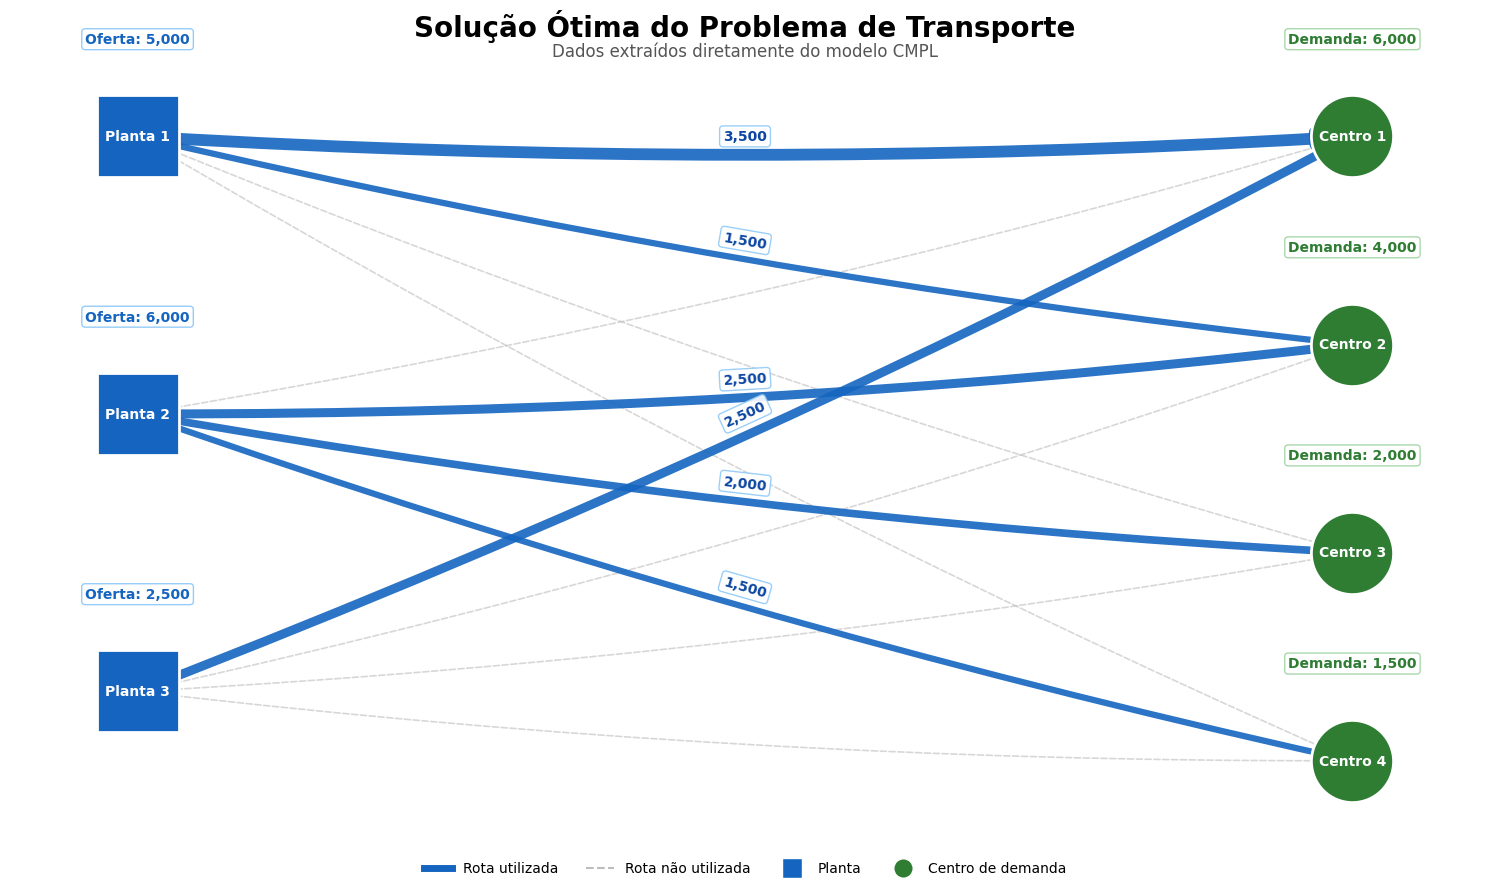

In [6]:
visualizar_transporte(modelo)

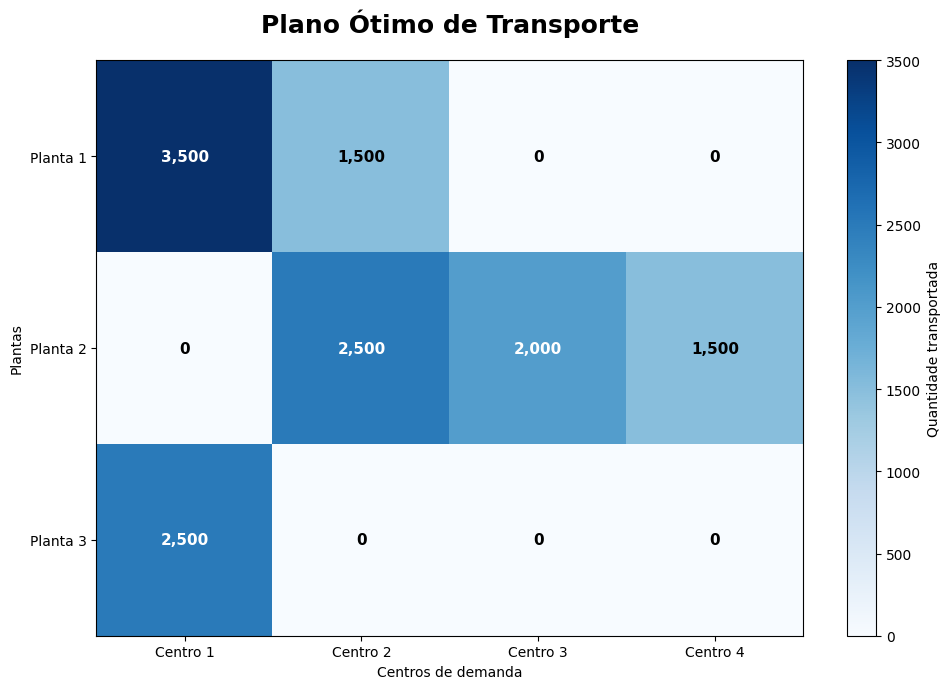

In [7]:
visualizar_heatmap(modelo)

# Source code

The source code is available on Github:
Cmpl official realeases: https://github.com/coin-or/Cmpl

Cmpl working git: https://github.com/MikeSteglich/Cmpl2

Coliop: https://github.com/MikeSteglich/Coliop

pyCmpl: https://github.com/MikeSteglich/pyCmpl3